# IMDb Movies Data Analysis

## Project Overview

This project explores a dataset of 10,000 IMDb movies to identify patterns and relationships in movie ratings, genres, release years, popularity, duration, Metascores, directors, and certificates.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load Dataset

In [2]:
df = pd.read_csv("imdb-movies-dataset.csv")

print(f"Dataset contains {df.shape[0]:,} movies and {df.shape[1]} columns.")

Dataset contains 10,000 movies and 15 columns.


## 3. Dataset Overview

First, we inspect the structure, columns, data types, summary statistics, missing values, and duplicate records.

In [3]:
print("First 5 rows:")
display(df.head())

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

First 5 rows:


,Poster,Title,Year,Certificate,Duration (min),Genre,Rating,Metascore,Director,Cast,Votes,Description,Review Count,Review Title,Review
0,https://m.media-amazon.com/images/M/MV5BYWRkZj...,The Idea of You,2023.0,R,115.0,"Comedy, Drama, Romance",6.4,67.0,Michael Showalter,"Anne Hathaway, Nicholas Galitzine, Ella Rubin,...","28,744","Solène, a 40-year-old single mom, begins an un...",166,Hypocrisy as an idea,"This film, as well as the reaction to it, is a..."
1,https://m.media-amazon.com/images/M/MV5BZGI4NT...,Kingdom of the Planet of the Apes,2023.0,PG-13,145.0,"Action, Adventure, Sci-Fi",7.3,66.0,Wes Ball,"Owen Teague, Freya Allan, Kevin Durand, Peter ...","22,248","Many years after the reign of Caesar, a young ...",183,A phenomenal start to another trilogy!,"I'm a big fan of all the planet of the apes, a..."
2,https://m.media-amazon.com/images/M/MV5BZjIyOT...,Unfrosted,2023.0,PG-13,97.0,"Biography, Comedy, History",5.5,42.0,Jerry Seinfeld,"Isaac Bae, Jerry Seinfeld, Chris Rickett, Rach...","18,401","In 1963 Michigan, business rivals Kellogg's an...",333,not funny,Pretty much the worst criticism you can lay on...
3,https://m.media-amazon.com/images/M/MV5BMjA5Zj...,The Fall Guy,2023.0,PG-13,126.0,"Action, Comedy, Drama",7.3,73.0,David Leitch,"Ryan Gosling, Emily Blunt, Aaron Taylor-Johnso...","38,953",A down-and-out stuntman must find the missing ...,384,Everything you needed and more!,Just got out of the Austin premier at SXSW and...
4,https://m.media-amazon.com/images/M/MV5BNTk1MT...,Challengers,2023.0,R,131.0,"Drama, Romance, Sport",7.7,82.0,Luca Guadagnino,"Zendaya, Mike Faist, Josh O'Connor, Darnell Ap...","32,517","Tashi, a former tennis prodigy turned coach, t...",194,"Watch ""Match Point"" instead",This is a tough one. I liked the concept and t...


Dataset shape: (10000, 15)

Column names:
['Poster', 'Title', 'Year', 'Certificate', 'Duration (min)', 'Genre', 'Rating', 'Metascore', 'Director', 'Cast', 'Votes', 'Description', 'Review Count', 'Review Title', 'Review']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Poster          10000 non-null  str    
 1   Title           10000 non-null  str    
 2   Year            9850 non-null   float64
 3   Certificate     7370 non-null   str    
 4   Duration (min)  9664 non-null   float64
 5   Genre           9993 non-null   str    
 6   Rating          9596 non-null   float64
 7   Metascore       7555 non-null   float64
 8   Director        9995 non-null   str    
 9   Cast            9961 non-null   str    
 10  Votes           9596 non-null   str    
 11  Description     10000 non-null  str    
 12  Review Count    9999 non-

In [4]:
print("Statistical summary:")
display(df.describe())

print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("Duplicate rows:", df.duplicated().sum())

Statistical summary:


,Year,Duration (min),Rating,Metascore
count,9850.000000,9664.000000,9596.000000,7555.000000
mean,2005.761421,108.809603,6.438610,58.068299
std,18.958005,23.159749,1.051412,17.845240
min,1929.000000,45.000000,1.300000,1.000000
25%,1997.000000,95.000000,5.800000,45.500000
50%,2012.000000,105.000000,6.500000,58.000000
75%,2021.000000,118.000000,7.200000,71.000000
max,2025.000000,746.000000,9.700000,100.000000


Missing values:


Certificate       2630
Metascore         2445
Review Title       517
Review             516
Votes              404
Rating             404
Duration (min)     336
Year               150
Cast                39
Genre                7
Director             5
Review Count         1
Title                0
Poster               0
Description          0
dtype: int64

Duplicate rows: 0


## 4. Data Cleaning

The dataset contains missing values in several columns. Rather than dropping large numbers of rows, we preserve useful observations and only transform values where appropriate.

`Votes` contains commas and must be converted to a numeric type. Missing certificates are labeled `Unknown`. Other missing numerical values are retained as `NaN` so that analyses can exclude them when necessary.

In [5]:
df_clean = df.copy()

# Clean Votes and convert to numeric
df_clean["Votes"] = (
    df_clean["Votes"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df_clean["Votes"] = pd.to_numeric(df_clean["Votes"], errors="coerce")

# Convert numerical columns
numeric_columns = [
    "Year", "Duration (min)", "Rating", "Metascore", "Review Count"
]

for column in numeric_columns:
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

# Handle missing certificates
df_clean["Certificate"] = df_clean["Certificate"].fillna("Unknown")

In [6]:
print("Data types after cleaning:")
print(df_clean.dtypes)

print("\nMissing values after cleaning:")
display(df_clean.isnull().sum().sort_values(ascending=False))

Data types after cleaning:
Poster                str
Title                 str
Year              float64
Certificate           str
Duration (min)    float64
Genre                 str
Rating            float64
Metascore         float64
Director              str
Cast                  str
Votes             float64
Description           str
Review Count      float64
Review Title          str
Review                str
dtype: object

Missing values after cleaning:


Metascore         2445
Review Title       517
Review             516
Review Count       435
Rating             404
Votes              404
Duration (min)     336
Year               150
Cast                39
Genre                7
Director             5
Certificate          0
Title                0
Poster               0
Description          0
dtype: int64

## 5. Exploratory Data Analysis

The following sections answer focused questions about the movie dataset.

### 5.1 IMDb Rating Distribution

How are IMDb ratings distributed across the movies in the dataset?

Average IMDb rating: 6.44
Median IMDb rating: 6.50
Minimum IMDb rating: 1.3
Maximum IMDb rating: 9.7


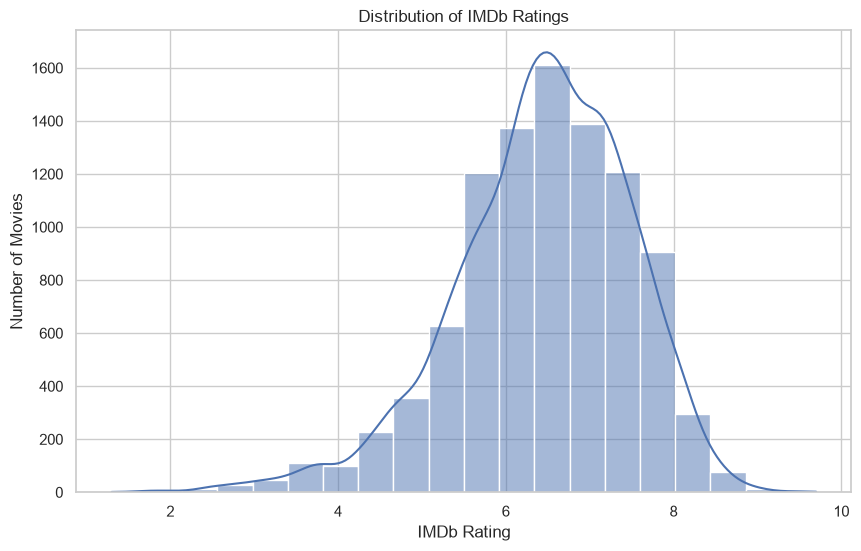

In [7]:
print(f"Average IMDb rating: {df_clean["Rating"].mean():.2f}")
print(f"Median IMDb rating: {df_clean["Rating"].median():.2f}")
print(f"Minimum IMDb rating: {df_clean["Rating"].min():.1f}")
print(f"Maximum IMDb rating: {df_clean["Rating"].max():.1f}")

plt.figure(figsize=(10, 6))
sns.histplot(df_clean["Rating"].dropna(), bins=20, kde=True)
plt.title("Distribution of IMDb Ratings")
plt.xlabel("IMDb Rating")
plt.ylabel("Number of Movies")
plt.show()

### 5.2 Genre Analysis

Which genres appear most often, and which genres have the highest average IMDb ratings? Because movies can have multiple genres, the genre combinations are also split into individual genres for analysis.

Top 15 Genre Combinations:


Genre
Drama                           504
Comedy, Drama, Romance          368
Drama, Romance                  360
Comedy                          302
Comedy, Drama                   292
Comedy, Romance                 241
Action, Crime, Drama            236
Animation, Adventure, Comedy    220
Action, Adventure, Comedy       194
Crime, Drama, Mystery           178
Horror, Mystery, Thriller       169
Horror, Thriller                166
Crime, Drama, Thriller          166
Action, Crime, Thriller         162
Horror                          161
Name: count, dtype: int64

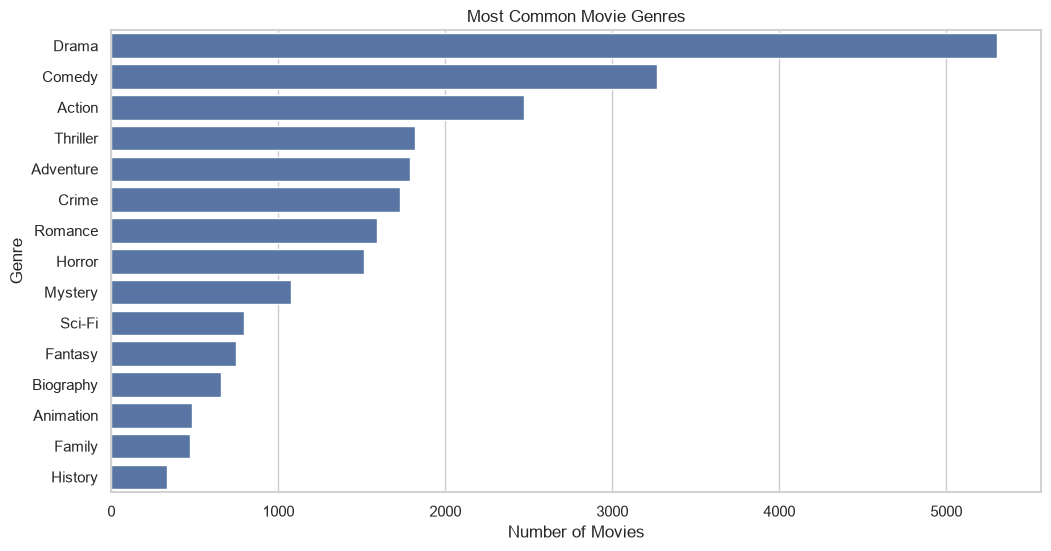

In [8]:
genre_combinations = df_clean["Genre"].value_counts().head(15)
print("Top 15 Genre Combinations:")
display(genre_combinations)

genre_list = (
    df_clean["Genre"]
    .dropna()
    .str.split(", ")
    .explode()
)
individual_genres = genre_list.value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=individual_genres.values, y=individual_genres.index)
plt.title("Most Common Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

Top genres by average IMDb rating (minimum 10 movies):


,mean,count
Genre,,
Film-Noir,7.675676,37
Documentary,7.307563,119
War,7.130612,196
Biography,7.080975,636
History,6.961371,321
Animation,6.854402,443
Western,6.803546,141
Music,6.723600,250
Drama,6.711173,5173


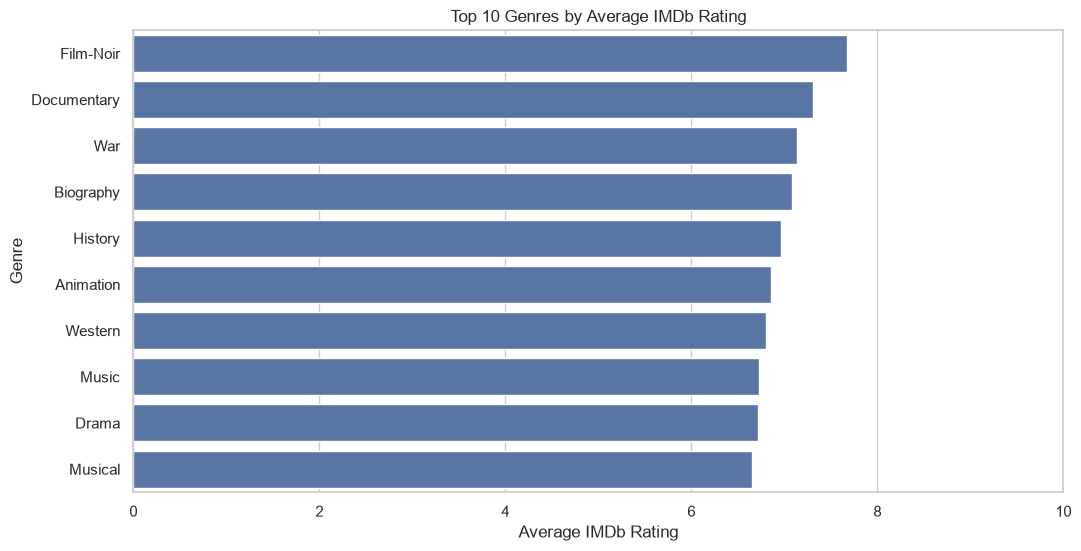

In [9]:
genre_data = df_clean.dropna(subset=["Genre", "Rating"]).copy()
genre_data["Genre"] = genre_data["Genre"].str.split(", ")

genre_rating = (
    genre_data
    .explode("Genre")
    .groupby("Genre")["Rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

# Require at least 10 movies for a more reliable comparison
reliable_genres = genre_rating[genre_rating["count"] >= 10]
print("Top genres by average IMDb rating (minimum 10 movies):")
display(reliable_genres.head(10))

top_genres = reliable_genres.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres["mean"], y=top_genres.index)
plt.title("Top 10 Genres by Average IMDb Rating")
plt.xlabel("Average IMDb Rating")
plt.ylabel("Genre")
plt.xlim(0, 10)
plt.show()

### 5.3 Movie Release Trends

How does the number of movies in the dataset vary by release year, and how does average rating change over time?

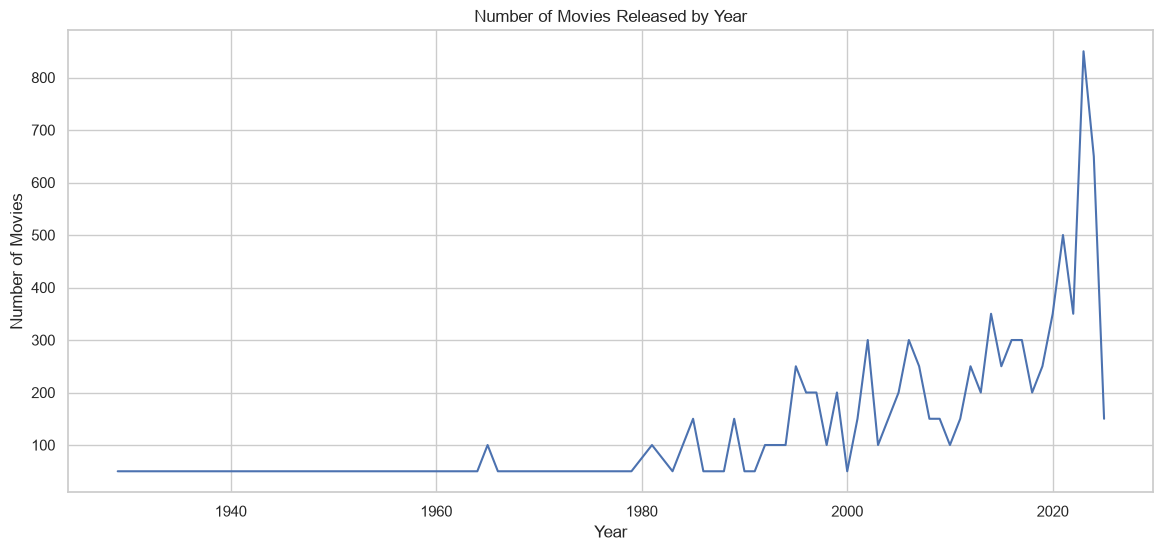

Top 10 years by number of movies:


Year
2023.0    850
2024.0    650
2021.0    500
2022.0    350
2014.0    350
2020.0    350
2002.0    300
2006.0    300
2016.0    300
2017.0    300
Name: count, dtype: int64

In [10]:
movies_by_year = (
    df_clean["Year"]
    .dropna()
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(x=movies_by_year.index, y=movies_by_year.values)
plt.title("Number of Movies Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

print("Top 10 years by number of movies:")
display(df_clean["Year"].dropna().value_counts().head(10))

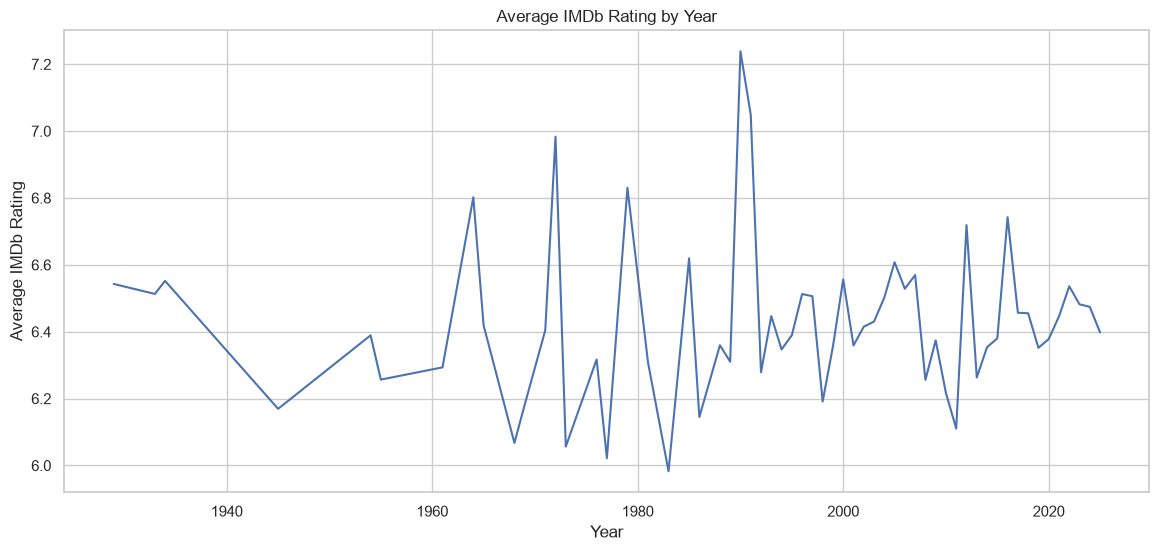

In [11]:
rating_by_year = (
    df_clean
    .dropna(subset=["Year", "Rating"])
    .groupby("Year")["Rating"]
    .mean()
)

plt.figure(figsize=(14, 6))
sns.lineplot(x=rating_by_year.index, y=rating_by_year.values)
plt.title("Average IMDb Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average IMDb Rating")
plt.show()

### 5.4 IMDb Rating vs Metascore

Do IMDb user ratings and Metascore ratings show a relationship?

Movies with both scores available: 7,555
Correlation between IMDb Rating and Metascore: 0.726


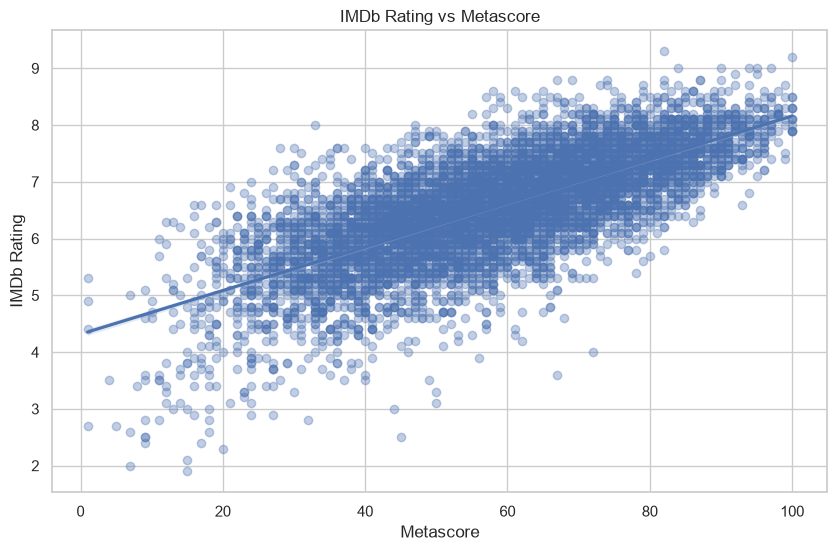

In [12]:
score_data = df_clean.dropna(subset=["Rating", "Metascore"])
correlation = score_data["Rating"].corr(score_data["Metascore"])

print(f"Movies with both scores available: {len(score_data):,}")
print(f"Correlation between IMDb Rating and Metascore: {correlation:.3f}")

plt.figure(figsize=(10, 6))
sns.regplot(
    data=score_data,
    x="Metascore",
    y="Rating",
    scatter_kws={"alpha": 0.35}
)
plt.title("IMDb Rating vs Metascore")
plt.xlabel("Metascore")
plt.ylabel("IMDb Rating")
plt.show()

### 5.5 IMDb Rating vs Number of Votes

Votes are used as a rough indicator of movie popularity. We examine whether popularity is associated with IMDb rating.

Movies with both Rating and Votes: 9,596
Correlation between IMDb Rating and Votes: 0.369


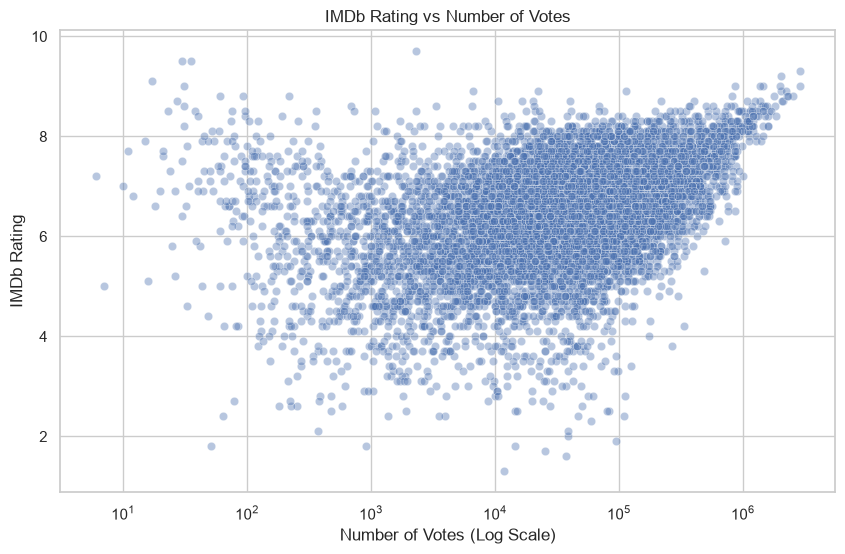

In [13]:
vote_data = df_clean.dropna(subset=["Rating", "Votes"]).copy()
correlation_votes = vote_data["Rating"].corr(vote_data["Votes"])

print(f"Movies with both Rating and Votes: {len(vote_data):,}")
print(f"Correlation between IMDb Rating and Votes: {correlation_votes:.3f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=vote_data, x="Votes", y="Rating", alpha=0.4)
plt.xscale("log")
plt.title("IMDb Rating vs Number of Votes")
plt.xlabel("Number of Votes (Log Scale)")
plt.ylabel("IMDb Rating")
plt.show()

Average IMDb Rating by Popularity Group:


Popularity
Low Votes            5.881659
Medium-Low Votes     6.338308
Medium-High Votes    6.507211
High Votes           7.027261
Name: Rating, dtype: float64

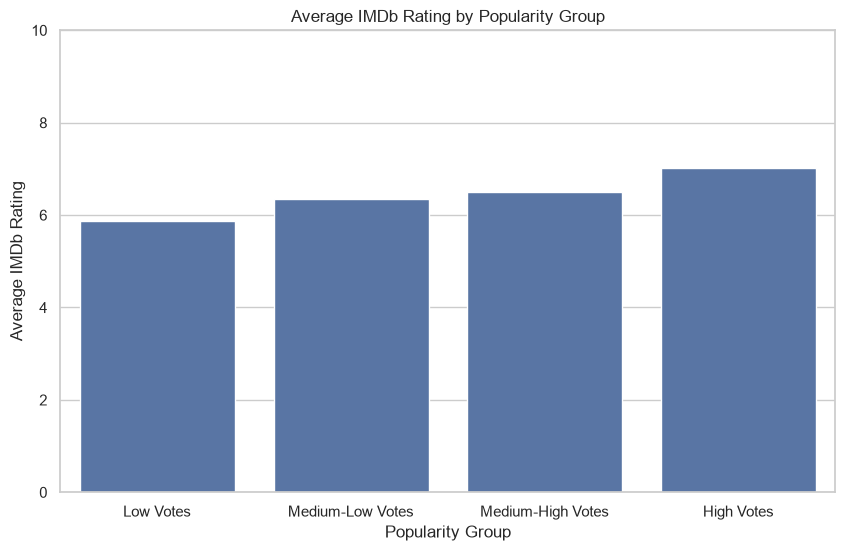

In [14]:
vote_data["Popularity"] = pd.qcut(
    vote_data["Votes"],
    q=4,
    labels=["Low Votes", "Medium-Low Votes", "Medium-High Votes", "High Votes"]
)

popularity_rating = vote_data.groupby("Popularity", observed=True)["Rating"].mean()
print("Average IMDb Rating by Popularity Group:")
display(popularity_rating)

plt.figure(figsize=(10, 6))
sns.barplot(x=popularity_rating.index, y=popularity_rating.values)
plt.title("Average IMDb Rating by Popularity Group")
plt.xlabel("Popularity Group")
plt.ylabel("Average IMDb Rating")
plt.ylim(0, 10)
plt.show()

### 5.6 Movie Duration vs IMDb Rating

Is movie runtime associated with IMDb rating?

Movies with both Duration and Rating: 9,587
Correlation between Duration and IMDb Rating: 0.360


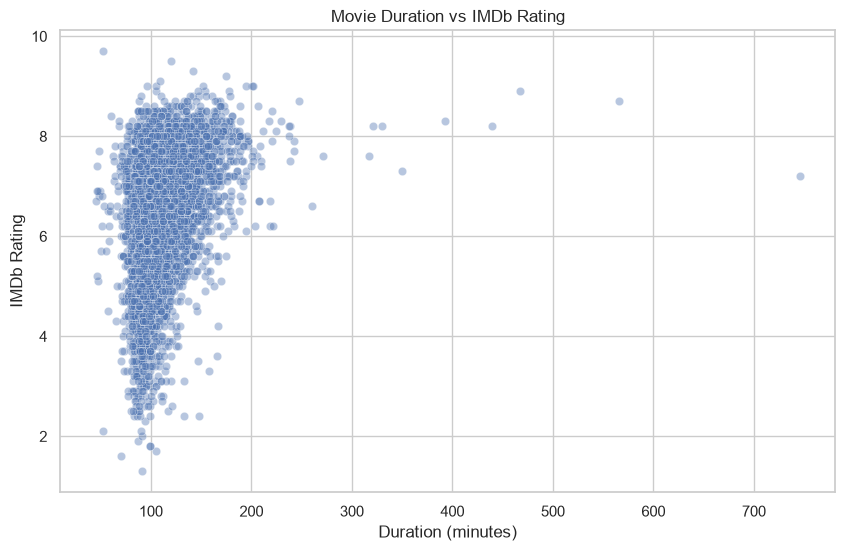

In [15]:
duration_data = df_clean.dropna(subset=["Duration (min)", "Rating"]).copy()
correlation_duration = duration_data["Duration (min)"].corr(duration_data["Rating"])

print(f"Movies with both Duration and Rating: {len(duration_data):,}")
print(f"Correlation between Duration and IMDb Rating: {correlation_duration:.3f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=duration_data, x="Duration (min)", y="Rating", alpha=0.4)
plt.title("Movie Duration vs IMDb Rating")
plt.xlabel("Duration (minutes)")
plt.ylabel("IMDb Rating")
plt.show()

Average IMDb Rating by Duration Group:


Duration Group
Under 90 min    5.913264
90-120 min      6.340594
120-150 min     7.007805
150+ min        7.438642
Name: Rating, dtype: float64

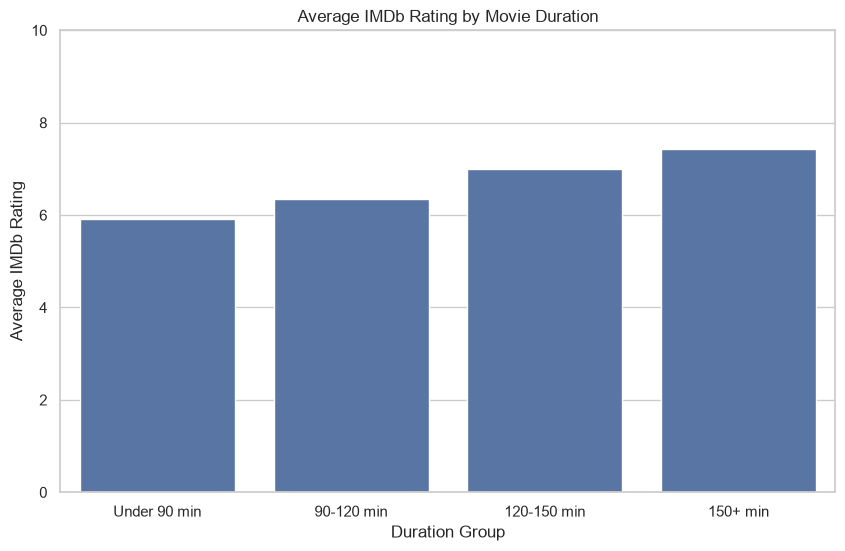

In [16]:
duration_data["Duration Group"] = pd.cut(
    duration_data["Duration (min)"],
    bins=[0, 90, 120, 150, 1000],
    labels=["Under 90 min", "90-120 min", "120-150 min", "150+ min"]
)

duration_rating = duration_data.groupby("Duration Group", observed=True)["Rating"].mean()
print("Average IMDb Rating by Duration Group:")
display(duration_rating)

plt.figure(figsize=(10, 6))
sns.barplot(x=duration_rating.index, y=duration_rating.values)
plt.title("Average IMDb Rating by Movie Duration")
plt.xlabel("Duration Group")
plt.ylabel("Average IMDb Rating")
plt.ylim(0, 10)
plt.show()

### 5.7 Director Analysis

Which directors have the highest average IMDb ratings? To avoid unstable rankings from directors with only one movie, we require at least three movies per director.

Top 10 Directors by Average IMDb Rating (minimum 3 movies):


,mean,count
Director,,
Charles Chaplin,8.400000,4
Sergio Leone,8.216667,6
Frank Capra,8.175000,4
Christopher Nolan,8.166667,12
Akira Kurosawa,8.160000,10
Pete Docter,8.125000,4
Stanley Kubrick,8.090909,11
Quentin Tarantino,8.081818,11
Ingmar Bergman,8.066667,6


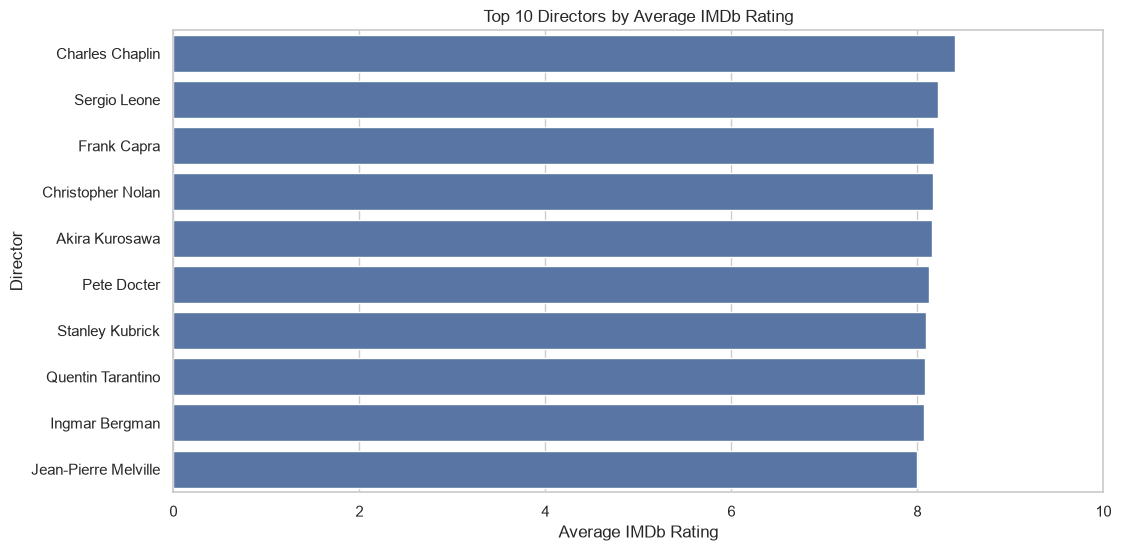

In [17]:
director_data = df_clean.dropna(subset=["Director", "Rating"])
director_stats = (
    director_data
    .groupby("Director")["Rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

reliable_directors = director_stats[director_stats["count"] >= 3]
top_directors = reliable_directors.head(10)

print("Top 10 Directors by Average IMDb Rating (minimum 3 movies):")
display(top_directors)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_directors["mean"], y=top_directors.index)
plt.title("Top 10 Directors by Average IMDb Rating")
plt.xlabel("Average IMDb Rating")
plt.ylabel("Director")
plt.xlim(0, 10)
plt.show()

Directors with the Most Movies:


Director
Clint Eastwood          35
Steven Spielberg        33
Ridley Scott            28
Martin Scorsese         26
Ron Howard              26
Steven Soderbergh       26
Alfred Hitchcock        24
Woody Allen             22
Robert Zemeckis         21
Francis Ford Coppola    20
Name: count, dtype: int64

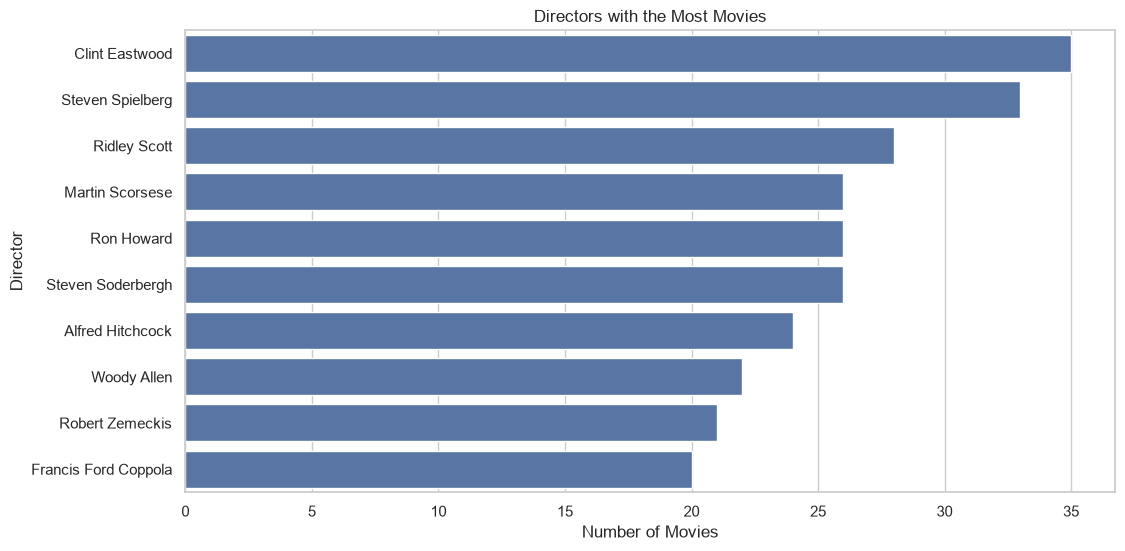

In [18]:
director_movie_count = df_clean["Director"].dropna().value_counts().head(10)

print("Directors with the Most Movies:")
display(director_movie_count)

plt.figure(figsize=(12, 6))
sns.barplot(x=director_movie_count.values, y=director_movie_count.index)
plt.title("Directors with the Most Movies")
plt.xlabel("Number of Movies")
plt.ylabel("Director")
plt.show()

### 5.8 Certificate Analysis

How are movies distributed across certificate categories, and how do average ratings differ? Certificate labels come from different classification systems, so this comparison is descriptive rather than a universal age-rating comparison.

Top 15 Certificate Categories:


Certificate
Unknown      2630
R            1704
A            1474
U            1265
UA           1193
PG-13         674
PG            253
18            199
Not Rated     165
16            107
13             74
UA 16+         60
UA 13+         43
7              35
15+            26
Name: count, dtype: int64

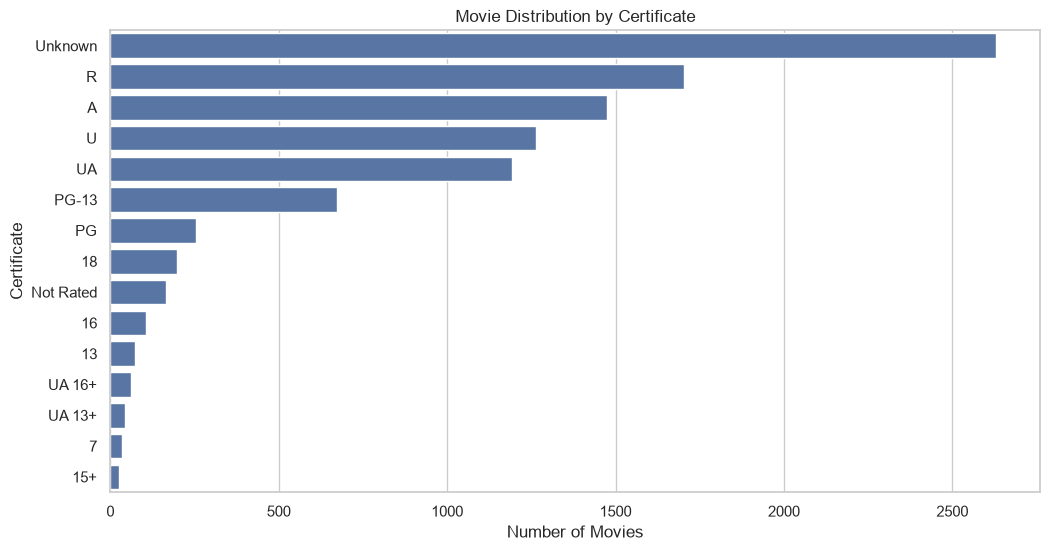

In [19]:
certificate_counts = df_clean["Certificate"].value_counts().head(15)
print("Top 15 Certificate Categories:")
display(certificate_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=certificate_counts.values, y=certificate_counts.index)
plt.title("Movie Distribution by Certificate")
plt.xlabel("Number of Movies")
plt.ylabel("Certificate")
plt.show()

Certificate categories with at least 10 rated movies:


,mean,count
Certificate,,
G,6.943750,16
12+,6.886667,15
U,6.744743,1265
Not Rated,6.725455,165
7,6.642857,35
UA,6.638055,1193
A,6.584193,1474
16,6.532710,107
UA 16+,6.455000,60


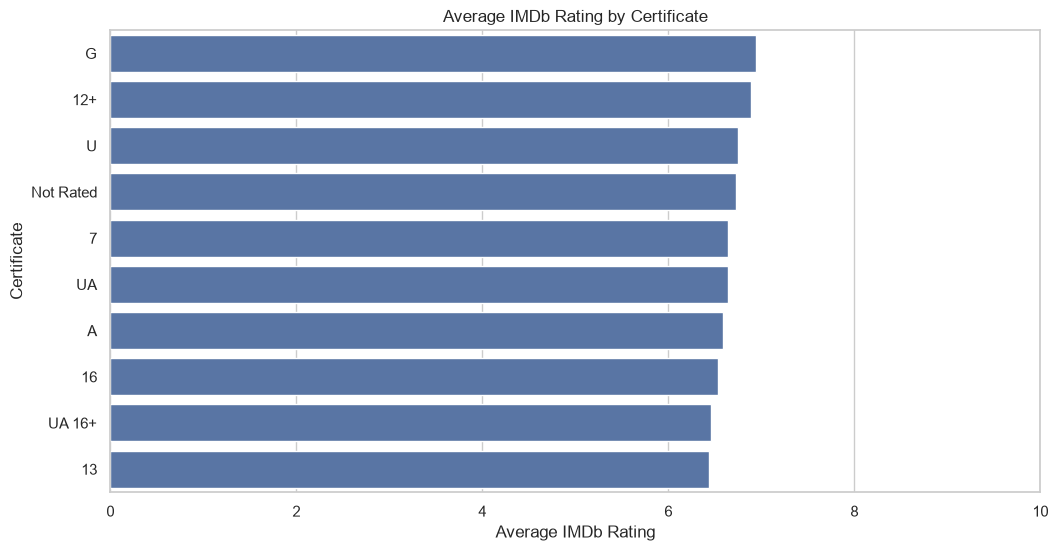

In [20]:
certificate_rating = (
    df_clean
    .dropna(subset=["Rating"])
    .groupby("Certificate")["Rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

reliable_certificates = certificate_rating[certificate_rating["count"] >= 10]
print("Certificate categories with at least 10 rated movies:")
display(reliable_certificates)

top_certificates = reliable_certificates.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_certificates["mean"], y=top_certificates.index)
plt.title("Average IMDb Rating by Certificate")
plt.xlabel("Average IMDb Rating")
plt.ylabel("Certificate")
plt.xlim(0, 10)
plt.show()

## 6. Key Findings

The analysis produced several notable patterns:

- The average IMDb rating in the dataset is approximately **6.44**, with a median of **6.50**.
- **Drama** is the most common individual genre, followed by Comedy and Action.
- Among genres with at least 10 movies, **Film-Noir** has the highest average IMDb rating in this dataset.
- IMDb Rating and Metascore show a **strong positive association** (correlation ≈ **0.73**).
- IMDb Rating and number of Votes show a **moderate positive association** (correlation ≈ **0.37**).
- IMDb Rating and movie Duration show a **moderate positive association** (correlation ≈ **0.36**).
- Directors with at least three movies can be compared more reliably than directors with only one movie; Charles Chaplin has the highest average rating among that filtered group.

These relationships indicate **association, not causation**. The analysis does not establish that duration, popularity, or Metascore causes IMDb ratings to change.

## 7. Conclusion

This project used Python, Pandas, Matplotlib, and Seaborn to clean and explore a 10,000-movie IMDb dataset. The analysis examined rating distributions, genres, release trends, Metascores, popularity, duration, directors, and certificates.

The project demonstrates a complete exploratory data-analysis workflow: understanding the dataset, cleaning relevant fields, analyzing relationships, visualizing patterns, and communicating data-driven findings.